# Antibody Developability Optimization — Evaluation

Loads all artifacts saved by the pipeline notebook and computes three
biophysical evaluation metrics:
1. **FoldX ΔΔG** — thermodynamic stability change vs parent (IgFold → FoldX)
2. **CamSol intrinsic solubility** — sequence-based solubility score
3. **Sequence SAP** — hydrophobic patch proxy for aggregation propensity

**Prerequisites:**
- Run the pipeline notebook first and confirm `eval_inputs/` is populated
- FoldX binary: download from https://foldxsuite.crg.eu (free academic)
  and upload as `foldx` to the project directory
- IgFold will be patched to work with the current transformers version

> Runtime → Change runtime type → **T4 GPU** before running.

---
## Section 0 — Installs

In [ ]:
# Install evaluation dependencies.
# igfold requires multiple compatibility patches (applied in Section 2).
!pip install -q igfold
!pip install -q ablang2 scikit-learn scipy matplotlib joblib
!pip install transformers==4.35.2 tokenizers==0.14.1

---
## Section 1 — Load All Pipeline Artifacts

In [ ]:
import os, json, importlib, subprocess, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.stats import ttest_rel, ttest_1samp
from scipy.spatial.distance import cdist as scipy_cdist
import joblib

from google.colab import drive
drive.mount('/content/drive')

# ── Paths — must match pipeline notebook exactly ──────────────────────────────
PROJECT_DIR = '/content/drive/MyDrive/project'
EVAL_DIR    = f'{PROJECT_DIR}/eval_inputs_oas_pretrain'
ORACLE_DIR  = f'{PROJECT_DIR}/eval_inputs'
STRUCT_DIR  = f'{PROJECT_DIR}/structures'
FOLDX_WORK  = f'{PROJECT_DIR}/foldx_work'
FOLDX_BIN   = f'{PROJECT_DIR}/foldx'
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

for d in [STRUCT_DIR, FOLDX_WORK]:
    if not os.path.exists(d): os.makedirs(d)

COL_VH   = 'vh_protein_sequence'
COL_VL   = 'vl_protein_sequence'
COL_NAME = 'antibody_name'
AA_VOCAB = list('ACDEFGHIKLMNPQRSTVWY')
CACHE    = lambda name: f'{PROJECT_DIR}/{name}'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Load DataFrames ───────────────────────────────────────────────────────────
compare_df = pd.read_csv(f'{EVAL_DIR}/compare_df.csv')
seq_df     = pd.read_csv(f'{EVAL_DIR}/seq_df.csv')
df         = pd.read_csv(f'{EVAL_DIR}/df_sequences.csv')
print(f'compare_df: {compare_df.shape}  seq_df: {seq_df.shape}')

# Restore CDR3 index lists from JSON
# (lists of lists cannot round-trip through CSV cleanly)
with open(f'{EVAL_DIR}/cdr3_idx.json') as f:
    cdr3_raw = json.load(f)
df['h_cdr3_idx'] = [cdr3_raw.get(str(i), []) for i in range(len(df))]

# ── Oracle models and scalers ─────────────────────────────────────────────────
oracle_hic  = joblib.load(f'{ORACLE_DIR}/oracle_hic.pkl')
oracle_sins = joblib.load(f'{ORACLE_DIR}/oracle_sins.pkl')
full_scaler = joblib.load(f'{ORACLE_DIR}/full_scaler.pkl')
cdr3_scaler = joblib.load(f'{EVAL_DIR}/cdr3_scaler.pkl')
fw_scaler   = joblib.load(f'{EVAL_DIR}/fw_scaler.pkl')
pls_model   = joblib.load(f'{EVAL_DIR}/pls_model.pkl')
pls_scaler  = joblib.load(f'{EVAL_DIR}/pls_scaler.pkl')
dev_scaler  = joblib.load(f'{EVAL_DIR}/dev_scaler.pkl')
print('Oracle models and scalers loaded.')

# ── PCA objects ───────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
pca      = joblib.load(f'{EVAL_DIR}/pca_cdr3.pkl')  # 50 components, CDR3 space
full_pca = joblib.load(f'{EVAL_DIR}/pca_full.pkl')  # 20 components, full-seq space
print(f'pca ({pca.n_components_} components)  '
      f'full_pca ({full_pca.n_components_} components)')

# ── Oracle targets (for z-scoring) ───────────────────────────────────────────
y_hic_train  = np.load(f'{ORACLE_DIR}/y_hic_train.npy')
y_sins_train = np.load(f'{ORACLE_DIR}/y_sins_train.npy')
y_hic_test   = np.load(f'{ORACLE_DIR}/y_hic_test.npy')
y_sins_test  = np.load(f'{ORACLE_DIR}/y_sins_test.npy')

# ── Split indices ─────────────────────────────────────────────────────────────
train_idx = np.load(f'{EVAL_DIR}/train_idx.npy')
test_idx  = np.load(f'{EVAL_DIR}/test_idx.npy')

# ── Scaled embeddings ─────────────────────────────────────────────────────────
X_cdr3_tr  = np.load(f'{EVAL_DIR}/X_cdr3_tr.npy')
X_cdr3_te  = np.load(f'{EVAL_DIR}/X_cdr3_te.npy')
X_fw_te    = np.load(f'{EVAL_DIR}/X_fw_te.npy')
X_full_tr  = np.load(f'{EVAL_DIR}/X_full_tr.npy')
X_full_te  = np.load(f'{EVAL_DIR}/X_full_te.npy')
train_pc20 = np.load(f'{EVAL_DIR}/train_pc20.npy')
print('Embeddings loaded.')

print(f'\nTest antibodies: {len(test_idx)}')
print(f'Generated sequences in compare_df: {len(compare_df)}')

compare_df: (50, 18)  seq_df: (50, 15)
Oracle models and scalers loaded.
pca (50 components)  full_pca (20 components)
Embeddings loaded.

Test antibodies: 50
Generated sequences in compare_df: 50


In [ ]:
# ── Reload AbLang2 (fast, no weights to save) ─────────────────────────────────
import ablang2
ablang = ablang2.pretrained(model_to_use='ablang2-paired',
                             random_init=False, ncpu=1, device=DEVICE)
ablang.freeze()
print('AbLang2 loaded.')

def oracle_score(vh_seq, vl_seq):
    """Score one (VH, VL) pair using seqcoding + Ridge oracle."""
    with torch.no_grad():
        emb = ablang([(vh_seq, vl_seq)], mode='seqcoding')
    emb_sc = full_scaler.transform(np.array(emb).reshape(1, -1))
    return {'hic':  float(oracle_hic.predict(emb_sc)[0]),
            'sins': float(oracle_sins.predict(emb_sc)[0])}

print('oracle_score() helper defined.')

AbLang2 loaded.
oracle_score() helper defined.


In [ ]:
# ── Re-score parent sequences with the canonical eval_inputs oracle ───────────
# compare_df was saved with oracle scores from the oas_pretrain pipeline run.
# We overwrite oracle_hic_parent and oracle_sins_parent using the shared oracle
# loaded from ORACLE_DIR to ensure comparability with eval_inputs results.

print("Re-scoring parent sequences with canonical oracle...")
new_hic, new_sins = [], []

for _, row in compare_df.iterrows():
    scores = oracle_score(row['parent_vh'], row['parent_vl'])
    new_hic.append(scores['hic'])
    new_sins.append(scores['sins'])

compare_df['oracle_hic_parent']  = new_hic
compare_df['oracle_sins_parent'] = new_sins

print(f"Oracle HIC parent:  {compare_df['oracle_hic_parent'].mean():+.3f} ± {compare_df['oracle_hic_parent'].sem():.3f}")
print(f"Oracle SINS parent: {compare_df['oracle_sins_parent'].mean():+.3f} ± {compare_df['oracle_sins_parent'].sem():.3f}")

In [ ]:
for variant in ['baseline', 'guided']:
    vh_col = f'{variant}_vh'
    new_hic, new_sins = [], []
    for _, row in compare_df.iterrows():
        scores = oracle_score(row[vh_col], row['parent_vl'])
        new_hic.append(scores['hic'])
        new_sins.append(scores['sins'])
    compare_df[f'oracle_hic_{variant}']  = new_hic
    compare_df[f'oracle_sins_{variant}'] = new_sins
    print(f"{variant} HIC: {compare_df[f'oracle_hic_{variant}'].mean():+.3f}  SINS: {compare_df[f'oracle_sins_{variant}'].mean():+.3f}")

---
## Section 2 — IgFold: Structure Prediction + CDR3 pLDDT

IgFold folds each (VH, VL) pair and returns per-residue pLDDT scores.
We report mean pLDDT over CDR3 residues as a structural confidence proxy.
Higher pLDDT = the model is more confident this CDR3 adopts a stable conformation.

**Note on compatibility patches:**
IgFold was built against an older version of the `transformers` library.
Several classes (`Trie`, `BasicTokenizer`, `WordpieceTokenizer`) have been
moved or removed in newer versions. We patch them in-place before importing
IgFold — this avoids a version downgrade that creates its own conflicts.

In [ ]:
# ── Patch transformers classes removed in newer versions ─────────────────────
# We define minimal stub classes that satisfy IgFold's checkpoint unpickling.
# These stubs do not need to be functionally correct — they just need to exist
# so pickle can deserialise the checkpoint without AttributeError.

import importlib, torch

# Reload torch.serialization to get the genuine original torch.load.
# Without this, running the cell multiple times causes _patched_load to call
# itself recursively (infinite recursion).
importlib.reload(torch.serialization)
import torch.serialization
_true_load = torch.serialization.load

try:
    import transformers.models.albert.tokenization_albert as _tus
except ImportError:
    import transformers.tokenization_utils as _tus
import transformers.models.bert.tokenization_bert as _bert_tok

if not hasattr(_tus, 'Trie'):
    class Trie:
        def __init__(self): self.data = {}
        def add(self, word):
            node = self.data
            for char in word: node = node.setdefault(char, {})
        def split(self, text): return [text]
    _tus.Trie = Trie
    print('Patched: Trie')

if not hasattr(_bert_tok, 'BasicTokenizer'):
    class BasicTokenizer:
        def __init__(self, do_lower_case=True, never_split=None,
                     tokenize_chinese_chars=True, strip_accents=None, **kw):
            self.do_lower_case = do_lower_case
        def tokenize(self, text, never_split=None):
            return text.lower().split() if self.do_lower_case else text.split()
    _bert_tok.BasicTokenizer = BasicTokenizer
    print('Patched: BasicTokenizer')

if not hasattr(_bert_tok, 'WordpieceTokenizer'):
    class WordpieceTokenizer:
        def __init__(self, vocab, unk_token='[UNK]',
                     max_input_chars_per_word=100, **kw):
            self.vocab     = vocab
            self.unk_token = unk_token
        def tokenize(self, text):
            return [text if text in self.vocab else self.unk_token]
    _bert_tok.WordpieceTokenizer = WordpieceTokenizer
    print('Patched: WordpieceTokenizer')

# Patch torch.load to allow weights_only=False (required for IgFold checkpoints)
from transformers.models.bert.configuration_bert import BertConfig
torch.serialization.add_safe_globals([BertConfig])

def _patched_load(f, *a, **kw):
    kw['weights_only'] = False
    return _true_load(f, *a, **kw)  # calls the reloaded original, never itself

torch.load = _patched_load
from igfold import IgFoldRunner
igfold = IgFoldRunner()
torch.load = _true_load  # restore immediately after loading
print('IgFold loaded.')

Patched: Trie

    The code, data, and weights for this work are made available for non-commercial use 
    (including at commercial entities) under the terms of the JHU Academic Software License 
    Agreement. For commercial inquiries, please contact awichma2[at]jhu.edu.
    License: https://github.com/Graylab/IgFold/blob/main/LICENSE.md
    
Loading 4 IgFold models...
Using device: cpu
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_1.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_2.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_3.ckpt...
Loading /usr/local/lib/python3.12/dist-packages/igfold/trained_models/IgFold/igfold_5.ckpt...
Successfully loaded 4 IgFold models.
Loaded AntiBERTy model.
IgFold loaded.


In [ ]:
def fold_and_save(vh, vl, ab_name, variant, cdr3_idx):
    """
    Fold one (VH, VL) pair with IgFold and save the PDB.
    Returns (pdb_path, cdr3_plddt, full_plddt).
    Uses cache: if PDB already exists, returns path without re-folding.
    """
    pdb_path = f'{STRUCT_DIR}/{ab_name}_{variant}.pdb'
    if os.path.exists(pdb_path):  # use cached structure
        return pdb_path, float('nan'), float('nan')
    try:
        preds   = igfold.fold(
            pdb_file  = pdb_path,
            sequences = {'H': vh, 'L': vl},
            do_refine = False,
            do_renum  = False)
        plddt   = preds.plddt.cpu().numpy()
        vh_pl   = plddt[:len(vh)]
        valid   = [i for i in cdr3_idx if i < len(vh_pl)]
        return (pdb_path,
                float(vh_pl[valid].mean()) if valid else float('nan'),
                float(vh_pl.mean()))
    except Exception as exc:
        print(f'  IgFold failed {ab_name} [{variant}]: {exc}')
        return None, float('nan'), float('nan')


print('Folding structures with IgFold (~30-60s per antibody × 3 variants)...')
pdb_records = []

for _, row in compare_df.iterrows():
    ab_name  = row['ab_name']
    df_rows  = df[df[COL_NAME] == ab_name]
    vl       = (row.get('parent_vl') or
                (df_rows[COL_VL].values[0] if len(df_rows) else ''))
    cdr3_idx = df_rows['h_cdr3_idx'].values[0] if len(df_rows) else []
    rec      = {'ab_name': ab_name}

    for variant, vh_col in [
            ('parent',   'parent_vh'),
            ('baseline', 'baseline_vh'),
            ('guided',   'guided_vh')]:
        vh = row.get(vh_col, row.get('parent_vh', ''))
        if not isinstance(vh, str) or not vh:
            rec[f'pdb_{variant}']        = None
            rec[f'plddt_cdr3_{variant}'] = float('nan')
            rec[f'plddt_full_{variant}'] = float('nan')
            continue
        pdb, cdr3_pl, full_pl = fold_and_save(
            vh, vl, ab_name, variant, cdr3_idx)
        rec[f'pdb_{variant}']        = pdb
        rec[f'plddt_cdr3_{variant}'] = cdr3_pl
        rec[f'plddt_full_{variant}'] = full_pl
        print(f'  ✓ {ab_name} [{variant}]  CDR3 pLDDT={cdr3_pl:.1f}')

    pdb_records.append(rec)

pdb_df = pd.DataFrame(pdb_records)

print('\nCDR3 pLDDT summary:')
for v in ['parent', 'baseline', 'guided']:
    vals = pdb_df[f'plddt_cdr3_{v}'].dropna()
    if len(vals):
        print(f'  {v:<10} {vals.mean():.2f} ± {vals.sem():.2f}')

Folding structures with IgFold (~30-60s per antibody × 3 variants)...
Completed folding in 33.25 seconds.
  IgFold failed abagovomab [parent]: 'IgFoldOutput' object has no attribute 'plddt'
  ✓ abagovomab [parent]  CDR3 pLDDT=nan
Completed folding in 31.76 seconds.
  IgFold failed abagovomab [baseline]: 'IgFoldOutput' object has no attribute 'plddt'
  ✓ abagovomab [baseline]  CDR3 pLDDT=nan
Completed folding in 32.64 seconds.
  IgFold failed abagovomab [guided]: 'IgFoldOutput' object has no attribute 'plddt'
  ✓ abagovomab [guided]  CDR3 pLDDT=nan
Completed folding in 36.42 seconds.
  IgFold failed abituzumab [parent]: 'IgFoldOutput' object has no attribute 'plddt'
  ✓ abituzumab [parent]  CDR3 pLDDT=nan
Completed folding in 33.58 seconds.
  IgFold failed abituzumab [baseline]: 'IgFoldOutput' object has no attribute 'plddt'
  ✓ abituzumab [baseline]  CDR3 pLDDT=nan
Completed folding in 29.97 seconds.
  IgFold failed abituzumab [guided]: 'IgFoldOutput' object has no attribute 'plddt'
  

KeyboardInterrupt: 

---
## Section 3 — FoldX ΔΔG

FoldX substitutes the CDR3 residues in the parent PDB (from IgFold) and
computes the change in folding free energy: ΔΔG = ΔG(variant) − ΔG(parent).
Negative ΔΔG = variant is more thermodynamically stable than the parent.

**Requirement:** FoldX Linux binary must be at `{PROJECT_DIR}/foldx`.
Download from https://foldxsuite.crg.eu (free academic registration).
After downloading and unzipping, run:
```
!cp {foldx_dir}/foldx_20241231 {PROJECT_DIR}/foldx
!chmod +x {PROJECT_DIR}/foldx
```
**Note:** FoldX requires identical CDR3 length between parent and variant.
This is guaranteed by our pipeline — we place exactly `len(parent_CDR3)`
mask tokens, so all generated CDR3s have the same length as the parent.

In [ ]:
foldx_available = os.path.exists(FOLDX_BIN)
print(f'FoldX binary: {"found ✓" if foldx_available else "NOT found"}')
if not foldx_available:
    print('Download from https://foldxsuite.crg.eu')
    print(f'Upload the Linux binary to {PROJECT_DIR} and run:')
    print(f'  !chmod +x {FOLDX_BIN}')


def build_mutation_string(parent_cdr3, variant_cdr3, cdr3_positions, chain='A'):
    """
    Build FoldX individual_list mutation string.
    Format per mutation: OrigAA + ChainID + ResNum + NewAA
    Example: YA100T means Tyr→Thr at position 100 on chain A.
    Returns None if sequences are identical (ΔΔG = 0 by definition).
    """
    if parent_cdr3 == variant_cdr3:
        return None
    muts = []
    for orig, new, pos in zip(parent_cdr3, variant_cdr3, cdr3_positions):
        if orig != new:
            muts.append(f'{orig}{chain}{pos+1}{new}')
    return ','.join(muts) + ';' if muts else None


def run_foldx(parent_pdb, mut_string, label):
    """
    Run FoldX BuildModel on the parent PDB with the given mutations.
    Returns ΔΔG in kcal/mol, or 0.0 if sequences are identical, or nan on failure.
    """
    if not foldx_available or parent_pdb is None: return float('nan')
    if mut_string is None: return 0.0  # identical CDR3 → no stability change

    mut_file = f'{FOLDX_WORK}/mutlist_{label}.txt'
    with open(mut_file, 'w') as f:
        f.write(mut_string + '\n')

    pdb_name = os.path.basename(parent_pdb)
    cmd = [FOLDX_BIN, '--command=BuildModel',
           f'--pdb={pdb_name}',
           f'--pdb-dir={os.path.dirname(parent_pdb)}',
           f'--mutant-file={mut_file}',
           f'--output-dir={FOLDX_WORK}',
           '--numberOfRuns=3', '--out-pdb=false', '--verbosity=0']
    try:
        out = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
        for line in out.stdout.split('\n'):
            if line.strip().startswith('Total'):
                return float(line.split()[1])
        # Fallback: read from Dif_ output file
        dif = f'{FOLDX_WORK}/Dif_{pdb_name.replace(".pdb","")}_1.fxout'
        if os.path.exists(dif):
            with open(dif) as f:
                for line in f.readlines()[9:]:
                    parts = line.strip().split('\t')
                    if len(parts) >= 2: return float(parts[1])
    except Exception as exc:
        print(f'  FoldX failed [{label}]: {exc}')
    return float('nan')


print('Computing FoldX ΔΔG...')
ddg_records = []

for _, pdb_row in pdb_df.iterrows():
    ab_name    = pdb_row['ab_name']
    comp_rows  = compare_df[compare_df['ab_name'] == ab_name]
    if not len(comp_rows): continue
    comp_row   = comp_rows.iloc[0]
    parent_pdb = pdb_row.get('pdb_parent')
    parent_cdr3= comp_row.get('parent_cdr3', '')
    df_rows    = df[df[COL_NAME] == ab_name]
    cdr3_idx   = df_rows['h_cdr3_idx'].values[0] if len(df_rows) else []
    rec        = {'ab_name': ab_name}

    for variant in ['baseline', 'guided']:
        var_cdr3 = comp_row.get(f'{variant}_cdr3', '')
        if (not isinstance(var_cdr3, str) or not var_cdr3
                or not isinstance(parent_cdr3, str)
                or len(var_cdr3) != len(parent_cdr3)
                or parent_pdb is None):
            rec[f'ddg_{variant}'] = float('nan')
            continue
        mut = build_mutation_string(parent_cdr3, var_cdr3, cdr3_idx)
        ddg = run_foldx(parent_pdb, mut, f'{ab_name}_{variant}')
        rec[f'ddg_{variant}'] = ddg
        print(f'  ✓ {ab_name} [{variant}]  ΔΔG={ddg:+.2f} kcal/mol')

    ddg_records.append(rec)

ddg_df = pd.DataFrame(ddg_records)
if foldx_available:
    print('\nΔΔG summary (negative = more stable than parent):')
    for v in ['baseline', 'guided']:
        vals = ddg_df[f'ddg_{v}'].dropna()
        if len(vals):
            print(f'  {v:<10} {vals.mean():+.3f} ± {vals.sem():.3f} kcal/mol')

FoldX binary: found ✓
Computing FoldX ΔΔG...

ΔΔG summary (negative = more stable than parent):


---
## Section 4 — CamSol Solubility + Sequence SAP

Both metrics are pure sequence-based — no structure, no installation required.

**CamSol** (Sormanni et al. 2015): assigns a per-residue solubility score based
on hydrophobicity and charge. Higher = more soluble = better.

**Sequence SAP**: approximates spatial aggregation propensity by counting
hydrophobic residues in a sliding window. Lower = less aggregation prone = better.
This is a sequence-level proxy for the structure-based DeepSP metric.

In [ ]:
# CamSol residue scores from Sormanni et al. 2015, Table 1
# Positive = solubility-promoting (charged residues)
# Negative = aggregation-prone (hydrophobic residues)
CAMSOL_SCORES = {
    'A':  0.0, 'R':  3.0, 'N':  1.0, 'D':  3.0, 'C': -1.0,
    'Q':  1.0, 'E':  3.0, 'G':  0.0, 'H':  0.5, 'I': -3.0,
    'L': -3.0, 'K':  3.0, 'M': -1.0, 'F': -3.0, 'P':  0.0,
    'S':  1.0, 'T':  1.0, 'W': -3.0, 'Y': -2.0, 'V': -2.0,
}
SAP_HYDROPHOBIC = {'A', 'V', 'I', 'L', 'M', 'F', 'W', 'Y'}


def camsol(seq):
    """CamSol intrinsic solubility — mean residue score over the sequence."""
    if not isinstance(seq, str) or not seq: return float('nan')
    return float(np.mean([CAMSOL_SCORES.get(aa.upper(), 0.0) for aa in seq]))


def sequence_sap(seq, window=5):
    """
    Sequence-based SAP approximation.
    Computes mean hydrophobic fraction in a sliding window of length 5.
    Higher = more hydrophobic patches = more aggregation prone = worse.
    """
    if not isinstance(seq, str) or not seq: return float('nan')
    scores = [1.0 if aa.upper() in SAP_HYDROPHOBIC else 0.0 for aa in seq]
    if len(seq) < window: return float(np.mean(scores))
    return float(np.mean([np.mean(scores[i:i+window])
                           for i in range(len(scores) - window + 1)]))


print('Computing CamSol and SAP scores...')
for variant, cdr3_col in [
        ('parent',   'parent_cdr3'),
        ('baseline', 'baseline_cdr3'),
        ('guided',   'guided_cdr3')]:
    compare_df[f'camsol_{variant}'] = compare_df[cdr3_col].apply(camsol)
    compare_df[f'sap_{variant}']    = compare_df[cdr3_col].apply(sequence_sap)

for metric, label, direction in [
        ('camsol', 'CamSol', 'higher=more soluble'),
        ('sap',    'SAP',    'lower=less aggregation prone')]:
    print(f'\n{label} ({direction}):')
    for v in ['parent', 'baseline', 'guided']:
        vals = compare_df[f'{metric}_{v}'].dropna()
        print(f'  {v:<10} {vals.mean():+.4f} ± {vals.sem():.4f}')

Computing CamSol and SAP scores...

CamSol (higher=more soluble):
  parent     -0.0043 ± 0.0556
  baseline   +0.1275 ± 0.1042
  guided     +0.3635 ± 0.0931

SAP (lower=less aggregation prone):
  parent     +0.4493 ± 0.0163
  baseline   +0.3390 ± 0.0252
  guided     +0.2998 ± 0.0251


---
## Section 5 — Merge Results + Summary Table + Figure

In [ ]:
# Merge pLDDT and ΔΔG into the main comparison dataframe
eval_df = compare_df.copy()

if 'pdb_df' in dir() and len(pdb_df):
    eval_df = eval_df.merge(
        pdb_df[['ab_name',
                'plddt_cdr3_parent', 'plddt_cdr3_baseline',
                'plddt_cdr3_guided']],
        on='ab_name', how='left')

if 'ddg_df' in dir() and len(ddg_df):
    eval_df = eval_df.merge(
        ddg_df[['ab_name', 'ddg_baseline', 'ddg_guided']],
        on='ab_name', how='left')

# ── Summary table ─────────────────────────────────────────────────────────────
def ms(col):
    """Format mean ± SE for a column, handling missing columns gracefully."""
    if col not in eval_df.columns: return '—'
    v = eval_df[col].dropna()
    return f'{v.mean():+.3f} ± {v.sem():.3f}' if len(v) else '—'


rows = [
    ('Oracle HIC (↓)',     'oracle_hic_parent',   'oracle_hic_baseline',   'oracle_hic_guided'),
    ('Oracle AC-SINS (↓)', 'oracle_sins_parent',  'oracle_sins_baseline',  'oracle_sins_guided'),
    ('CamSol (↑)',          'camsol_parent',        'camsol_baseline',       'camsol_guided'),
    ('SAP (↓)',             'sap_parent',           'sap_baseline',          'sap_guided'),
    ('CDR3 pLDDT (↑)',      'plddt_cdr3_parent',   'plddt_cdr3_baseline',   'plddt_cdr3_guided'),
    ('FoldX ΔΔG (↓)',       None,                   'ddg_baseline',          'ddg_guided'),
]

print('=' * 72)
print(f'  {"Metric":<24} {"Parent":<18} {"Baseline":<18} {"Guided"}')
print('=' * 72)
for label, pc, bc, gc in rows:
    pv = ms(pc) if pc else '— (ref)'
    print(f'  {label:<24} {pv:<18} {ms(bc):<18} {ms(gc)}')
print('=' * 72)
print('mean ± SE across test antibodies.  ↓ lower better.  ↑ higher better.')

  Metric                   Parent             Baseline           Guided
  Oracle HIC (↓)           +2.773 ± 0.022     +2.706 ± 0.020     +2.682 ± 0.020
  Oracle AC-SINS (↓)       +1.625 ± 0.052     +1.612 ± 0.052     +1.585 ± 0.052
  CamSol (↑)               -0.004 ± 0.056     +0.128 ± 0.104     +0.364 ± 0.093
  SAP (↓)                  +0.449 ± 0.016     +0.339 ± 0.025     +0.300 ± 0.025
  CDR3 pLDDT (↑)           —                  —                  —
  FoldX ΔΔG (↓)            — (ref)            —                  —
mean ± SE across test antibodies.  ↓ lower better.  ↑ higher better.


In [ ]:
# ── Paired t-tests ────────────────────────────────────────────────────────────
# Paired across the ~49 test antibodies.
# N=49 is too small for unpaired tests — the paired structure removes
# between-antibody variance and gives sufficient power.

print('\nPaired t-tests vs parent (* = p < 0.05):')
print(f'  {"Metric":<22} {"Baseline Δ / p":<24} {"Guided Δ / p"}')
print('  ' + '─' * 60)

test_pairs = [
    ('Oracle HIC',  'oracle_hic_baseline',  'oracle_hic_parent',
                    'oracle_hic_guided',    'oracle_hic_parent'),
    ('Oracle SINS', 'oracle_sins_baseline', 'oracle_sins_parent',
                    'oracle_sins_guided',   'oracle_sins_parent'),
    ('CamSol',      'camsol_baseline',       'camsol_parent',
                    'camsol_guided',         'camsol_parent'),
    ('SAP',         'sap_baseline',          'sap_parent',
                    'sap_guided',            'sap_parent'),
    ('CDR3 pLDDT',  'plddt_cdr3_baseline',  'plddt_cdr3_parent',
                    'plddt_cdr3_guided',    'plddt_cdr3_parent'),
]

for label, bc, bref, gc, gref in test_pairs:
    res = []
    for col, ref in [(bc, bref), (gc, gref)]:
        if col not in eval_df.columns or ref not in eval_df.columns:
            res.append('—'); continue
        a  = eval_df[col].dropna()
        b  = eval_df[ref].reindex(a.index).dropna()
        if len(a) < 3: res.append('—'); continue
        _, p = ttest_rel(a, b, nan_policy='omit')
        d    = (a - b).mean()
        res.append(f'Δ={d:+.3f} p={p:.3f}{"*" if p < 0.05 else ""}')
    print(f'  {label:<22} {res[0]:<24} {res[1]}')


Paired t-tests vs parent (* = p < 0.05):
  Metric                 Baseline Δ / p           Guided Δ / p
  ────────────────────────────────────────────────────────────
  Oracle HIC             Δ=-0.067 p=0.000*        Δ=-0.091 p=0.000*
  Oracle SINS            Δ=-0.014 p=0.283         Δ=-0.041 p=0.002*
  CamSol                 Δ=+0.132 p=0.269         Δ=+0.368 p=0.002*
  SAP                    Δ=-0.110 p=0.001*        Δ=-0.150 p=0.000*
  CDR3 pLDDT             —                        —


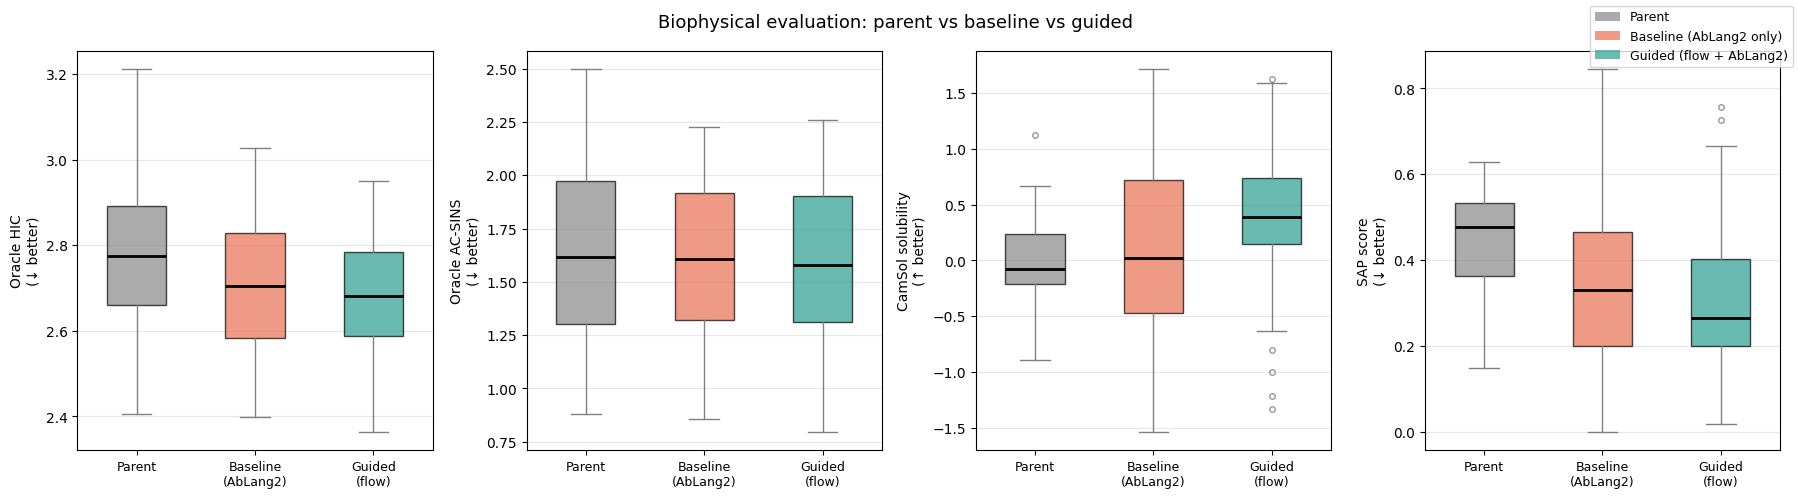

Figure saved → /content/drive/MyDrive/project/biophysical_evaluation.png


In [ ]:
# ── Figure: all metrics side by side ──────────────────────────────────────────
metrics_plot = [
    (m, l) for m, l in [
        ('oracle_hic',  'Oracle HIC\n(↓ better)'),
        ('oracle_sins', 'Oracle AC-SINS\n(↓ better)'),
        ('camsol',      'CamSol solubility\n(↑ better)'),
        ('sap',         'SAP score\n(↓ better)'),
        ('plddt_cdr3',  'CDR3 pLDDT\n(↑ better)'),
        ('ddg',         'FoldX ΔΔG\n(↓ better)'),
    ]
    if f'{m}_guided' in eval_df.columns
    and eval_df[f'{m}_guided'].notna().sum() > 0
]

palette = {'parent': '#888888', 'baseline': '#e76f51', 'guided': '#2a9d8f'}
ncols = max(len(metrics_plot), 1)
fig, axes = plt.subplots(1, ncols, figsize=(4.5 * ncols, 5))
if ncols == 1: axes = [axes]

for ax, (prefix, label) in zip(axes, metrics_plot):
    data = [eval_df.get(f'{prefix}_{c}',
                        pd.Series(dtype=float)).dropna()
            for c in ['parent', 'baseline', 'guided']]
    bp = ax.boxplot(data, positions=range(3), widths=0.5,
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(color='grey'),
                    capprops=dict(color='grey'),
                    flierprops=dict(marker='o', alpha=0.4, ms=4))
    for patch, c in zip(bp['boxes'], ['parent', 'baseline', 'guided']):
        patch.set_facecolor(palette[c]); patch.set_alpha(0.7)
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Parent', 'Baseline\n(AbLang2)', 'Guided\n(flow)'],
                        fontsize=9)
    ax.set_ylabel(label); ax.grid(True, axis='y', alpha=0.3)

legend_elements = [
    Patch(facecolor=palette['parent'],   alpha=0.7, label='Parent'),
    Patch(facecolor=palette['baseline'], alpha=0.7, label='Baseline (AbLang2 only)'),
    Patch(facecolor=palette['guided'],   alpha=0.7, label='Guided (flow + AbLang2)'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=9)
plt.suptitle('Biophysical evaluation: parent vs baseline vs guided', fontsize=13)
plt.tight_layout()
plt.savefig(CACHE('biophysical_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {CACHE("biophysical_evaluation.png")}')

In [ ]:
from scipy.stats import ttest_rel

# ── Compute CamSol and SAP for all conditions if not already done ─────────────
CAMSOL_SCORES = {
    'A':  0.0, 'R':  3.0, 'N':  1.0, 'D':  3.0, 'C': -1.0,
    'Q':  1.0, 'E':  3.0, 'G':  0.0, 'H':  0.5, 'I': -3.0,
    'L': -3.0, 'K':  3.0, 'M': -1.0, 'F': -3.0, 'P':  0.0,
    'S':  1.0, 'T':  1.0, 'W': -3.0, 'Y': -2.0, 'V': -2.0,
}
SAP_HYDROPHOBIC = {'A', 'V', 'I', 'L', 'M', 'F', 'W', 'Y'}

def camsol(seq):
    if not isinstance(seq, str) or not seq: return float('nan')
    return float(np.mean([CAMSOL_SCORES.get(aa.upper(), 0.0) for aa in seq]))

def sequence_sap(seq, window=5):
    if not isinstance(seq, str) or not seq: return float('nan')
    scores = [1.0 if aa.upper() in SAP_HYDROPHOBIC else 0.0 for aa in seq]
    if len(seq) < window: return float(np.mean(scores))
    return float(np.mean([np.mean(scores[i:i+window])
                           for i in range(len(scores) - window + 1)]))

for variant, col in [('parent',   'parent_cdr3'),
                      ('baseline', 'baseline_cdr3'),
                      ('guided',   'guided_cdr3')]:
    if f'camsol_{variant}' not in compare_df.columns:
        compare_df[f'camsol_{variant}'] = compare_df[col].apply(camsol)
    if f'sap_{variant}' not in compare_df.columns:
        compare_df[f'sap_{variant}']    = compare_df[col].apply(sequence_sap)

# ── Summary table ─────────────────────────────────────────────────────────────
metrics = [
    ('oracle_hic',  'Oracle HIC (↓)',  'lower'),
    ('oracle_sins', 'Oracle SINS (↓)', 'lower'),
    ('camsol',      'CamSol (↑)',       'higher'),
    ('sap',         'SAP (↓)',          'lower'),
]

print(f'{"Metric":<22} {"Parent":>18} {"Baseline":>18} {"Guided":>18}')
print('─' * 78)
for prefix, label, _ in metrics:
    row = []
    for v in ['parent', 'baseline', 'guided']:
        col  = f'{prefix}_{v}'
        vals = compare_df[col].dropna() if col in compare_df.columns \
               else pd.Series(dtype=float)
        row.append(f'{vals.mean():+.3f}±{vals.sem():.3f}' if len(vals) else '—')
    print(f'{label:<22} {row[0]:>18} {row[1]:>18} {row[2]:>18}')

# ── Paired t-tests ─────────────────────────────────────────────────────────────
print(f'\nPaired t-tests (* = p < 0.05):\n')
print(f'{"Metric":<8} {"Baseline vs Parent":>28} '
      f'{"Guided vs Parent":>26} {"Guided vs Baseline":>26}')
print('─' * 104)

comparisons = [
    ('Baseline vs Parent', 'baseline', 'parent'),
    ('Guided vs Parent',   'guided',   'parent'),
    ('Guided vs Baseline', 'guided',   'baseline'),
]

for prefix, label, direction in metrics:
    row_parts = [f'{label:<22}']
    for comp_label, v1, v2 in comparisons:
        c1 = f'{prefix}_{v1}'
        c2 = f'{prefix}_{v2}'
        if c1 not in compare_df.columns or c2 not in compare_df.columns:
            row_parts.append(f'{"—":>26}')
            continue
        a  = compare_df[c1].dropna()
        b  = compare_df[c2].reindex(a.index).dropna()
        if len(a) < 3:
            row_parts.append(f'{"—":>26}')
            continue
        _, p = ttest_rel(a, b, nan_policy='omit')
        d    = (a - b).mean()
        sig  = '*' if p < 0.05 else ' '
        row_parts.append(f'Δ={d:+.3f} p={p:.3f}{sig}')
    print('  '.join(row_parts))

print('\nFor ↓ metrics: Δ < 0 = improvement.')
print('For ↑ metrics: Δ > 0 = improvement.')

Metric                             Parent           Baseline             Guided
──────────────────────────────────────────────────────────────────────────────
Oracle HIC (↓)               +2.773±0.022       +2.706±0.020       +2.682±0.020
Oracle SINS (↓)              +1.625±0.052       +1.612±0.052       +1.585±0.052
CamSol (↑)                   -0.004±0.056       +0.128±0.104       +0.364±0.093
SAP (↓)                      +0.449±0.016       +0.339±0.025       +0.300±0.025

Paired t-tests (* = p < 0.05):

Metric             Baseline vs Parent           Guided vs Parent         Guided vs Baseline
────────────────────────────────────────────────────────────────────────────────────────────────────────
Oracle HIC (↓)          Δ=-0.067 p=0.000*  Δ=-0.091 p=0.000*  Δ=-0.024 p=0.000*
Oracle SINS (↓)         Δ=-0.014 p=0.283   Δ=-0.041 p=0.002*  Δ=-0.027 p=0.016*
CamSol (↑)              Δ=+0.132 p=0.269   Δ=+0.368 p=0.002*  Δ=+0.236 p=0.135 
SAP (↓)                 Δ=-0.110 p=0.001*  Δ=-0.150